<a href="https://colab.research.google.com/github/rojaspetit/analysis-telecom/blob/main/tt_telecom_connectatel_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('datasets/plans.csv')
users = pd.read_csv('datasets/users_latam.csv')
usage = pd.read_csv('datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de nulos en users:\n", users.isna().sum().sort_values(ascending=False))
print("Proporción de nulos en users:\n", users.isna().mean().sort_values(ascending=False))

Cantidad de nulos en users:
 churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64
Proporción de nulos en users:
 churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de nulos en usage:\n", usage.isna().sum().sort_values(ascending=False))
print("Proporción de nulos en usage:\n", usage.isna().mean().sort_values(ascending=False))

Cantidad de nulos en usage:
 duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64
Proporción de nulos en usage:
 duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
*   Dataset users: faltantes en columnas **city** (11.72%) y **chrun_date** (88.35%)
*   Dataset usage: faltantes en columas **date** (0.1%), **duration** (55.19%) y **length** (44.74%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
*   Dataset users: columna **city**, se revisa para imputar valor. Columna **churn_date** no necesariamente es un problema de calidad, pues indica que un usuario sigue activo.
*   Dataset usage: columna **date** se revisa para imputar o eliminar. Columnas **duration** y **length** no neceseriamente son errores, pues parecen depender de si **type** es "call" o "text".

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

print("Exploración de user_id:\n", users["user_id"].describe())
print("Exploración de age:\n", users["age"].describe())
print("Sentinels en age:", users["age"].isin([-999]).sum())

Exploración de user_id:
 count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
Exploración de age:
 count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
Sentinels en age: 55


- La columna `user_id` es una columna de identificadores, sin valores duplicados o nulos. La data no indica anomalías.
- La columna `age` tiene un sentinel / valor inválido como -999, presente en el 1.3% de los casos.

In [ ]:
# explorar columnas numéricas de usage

print("Exploración de id:\n", usage["id"].describe())
print("Exploración de user_id:\n", usage["user_id"].describe())

Exploración de id:
 count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
Exploración de user_id:
 count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


- Las columnas `id` y `user_id`son identificadores de la operación (id) y el usuario que la realiza (user_id)
- Las columna `id` es una columna de identificadores, sin valores duplicados o nulos. La data no indica anomalías.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print("Exploración de city y plan:\n", users[columnas_user].describe())
print("Conteo de valores por city y plan:\n", users[columnas_user].value_counts())
print("Proporción de city con '?':", (users["city"] == "?").mean())

Exploración de city y plan:
           city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
Conteo de valores por city y plan:
 city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64
Proporción de city con '?': 0.024


- La columna `city` cuenta con 7 valores únicos, entre los cuales está el sentinel "?", presente en el 2.4% de los casos.
- La columna `plan` solo cuenta con 2 renglones (planes), de los cuales el plan "Básico" es el predominante.

In [ ]:
# explorar columna categórica de usage

print("Exploración de type:\n", usage['type'].describe())
print("Conteo de valores de type:\n", usage['type'].value_counts())

Exploración de type:
 count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
Conteo de valores de type:
 text    22092
call    17908
Name: type, dtype: int64


- La columna `type` tiene 2 valores únicos, de los cuales el predominante es "text". Esta sería la operación más realizada por sus usuarios, de acuerdo a los datos disponibles.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? Columna **age** de users (-999). Columna **city** de users ("?").
- ¿Qué acción tomarías? Reemplazar/Imputar el sentinel con un estadístico que represente al dataset (**age**) o el valor "unkown" (**city**)

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, del total de registros, tenemos 40 (1.0%) que muestran un año imposible (2026).

In [ ]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros no-nulos son del año 2024.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Si, 2026 (de acuerdo a la data proporcionada)
- ¿Qué harías con ellas? Marcar como nulos (NaN) las fechas fuera de rango.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnóstico: Los valores nulos en duration y length dependen directamente del tipo de actividad (type). duration es nulo casi exclusivamente en mensajes de texto, mientras que length es nulo en las llamadas. Por lo tanto, se consideran nulos asociados al tipo de evento y se mantienen sin imputar.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
})

# observar resultado
usage_agg.head(3)

,is_text,is_call,duration
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamados"
})

# observar resultado
usage_agg.head(3)

,cant_mensajes,cant_llamadas,cant_minutos_llamados
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_num=["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamados"]
user_profile[columnas_num].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamados
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

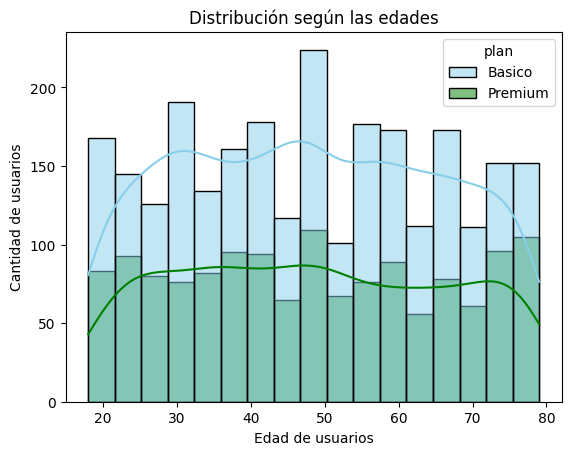

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Edad de usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución según las edades")
plt.show()

💡Insights:
- Distribución relativamente uniforme/simétrica.
- No se identifica un patrón claro entre la edad y el tipo de plan.

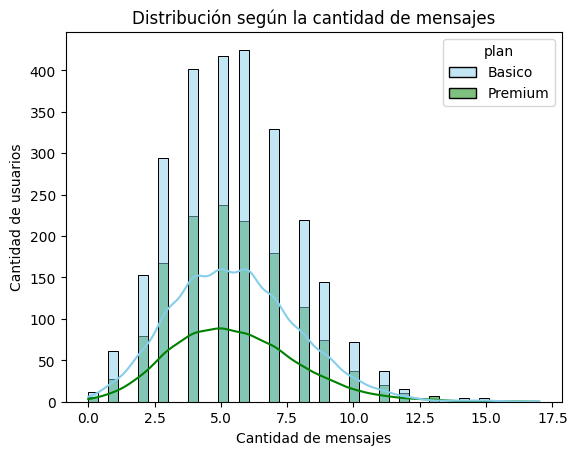

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución según la cantidad de mensajes")
plt.show()

💡Insights:
- Distribución sesgada a la derecha.
- La mayor proporción de usuarios envío entre 4 y 7 mensajes, en ambos planes.

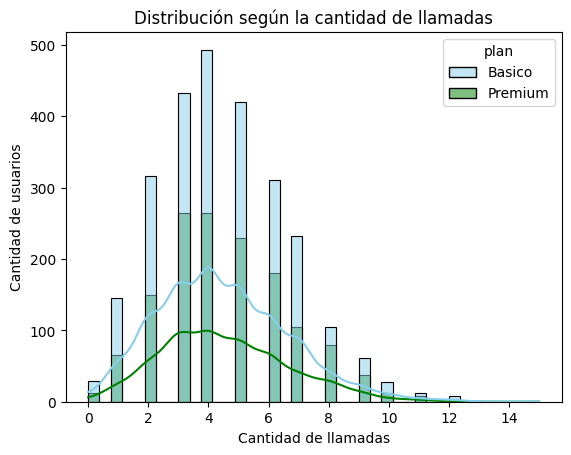

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución según la cantidad de llamadas")
plt.show()

💡Insights:
- Distribución sesgada a la derecha.
- La mayor proporción de usuarios realizó entre 3 y 6 llamadas, con un patrón similar en ambos planes.

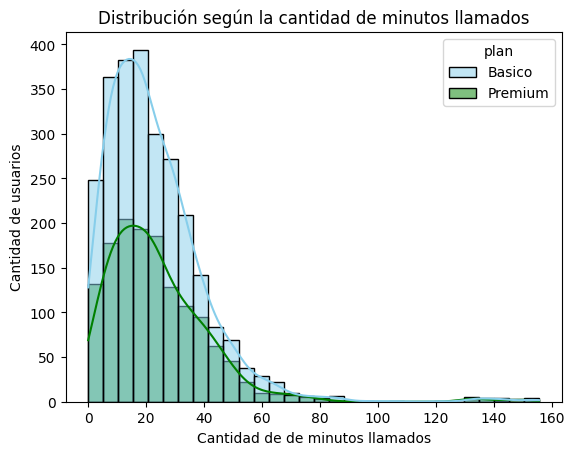

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamados", bins=30, hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de de minutos llamados")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución según la cantidad de minutos llamados")
plt.show()

💡Insights:
- Distribución sesgada a la derecha
- La mayoría de usuarios se concentra entre los 10 y 30 minutos totales en llamadas, con valores extremos elevados.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

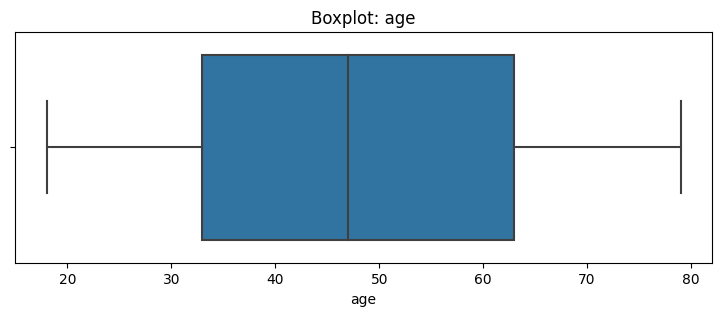

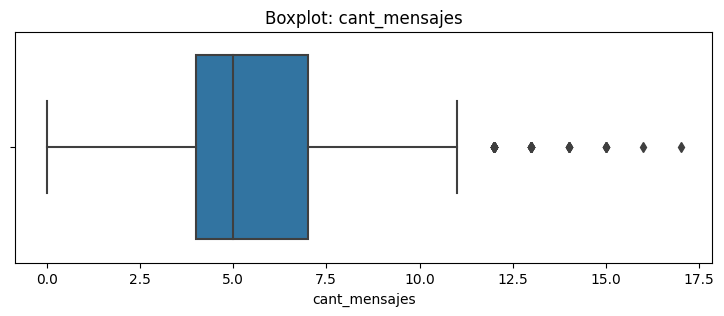

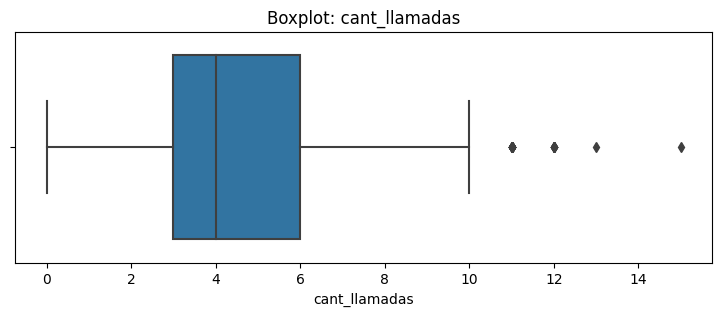

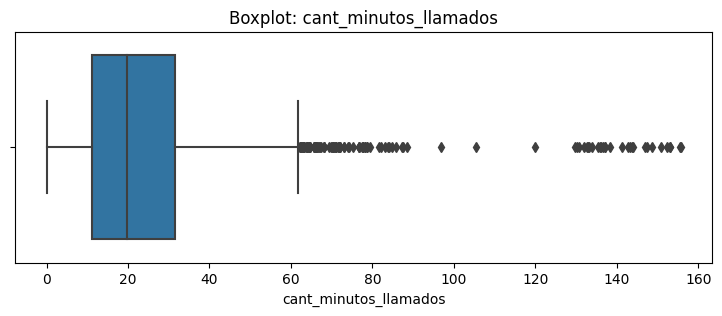

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamados']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers.
- cant_mensajes: tiene outliers superiores.
- cant_llamadas: tiene outliers superiores.
- cant_minutos_llamada: tiene outliers superiores.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamados']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    print(col, "IQR: ", IQR)

    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    display(user_profile[(user_profile[col] > upper) | (user_profile[col] < lower)].head(5))


cant_mensajes IQR:  3.0


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados
315,10315,Carlos,Lopez,30.0,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13.0,3.0,12.36
347,10347,Carlos,Garcia,77.0,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13.0,3.0,21.40
356,10356,Mateo,Garcia,42.0,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12.0,5.0,59.48
384,10384,Sofia,Ramirez,35.0,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN,12.0,3.0,13.05
456,10456,Mateo,Ramirez,47.0,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18",12.0,1.0,2.24


cant_llamadas IQR:  3.0


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados
116,10116,Ana,Garcia,52.0,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3.0,11.0,44.32
417,10417,Luis,Garcia,70.0,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4.0,12.0,26.42
777,10777,Sofia,Lopez,65.0,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4.0,12.0,55.28
778,10778,Mateo,Lopez,77.0,NaN,2022-08-02 00:44:17.464366092,Basico,NaN,8.0,11.0,32.13
862,10862,Luis,Ramirez,23.0,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN,4.0,15.0,78.11


cant_minutos_llamados IQR:  20.295


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados
27,10027,Ana,Gomez,28.0,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8.0,7.0,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6.0,5.0,152.36
93,10093,Ana,Torres,67.0,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2.0,7.0,71.57
189,10189,Mariana,Torres,63.0,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9.0,4.0,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18",8.0,9.0,78.77


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamados
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener outliers pues representan un comportamiento real.
- cant_llamadas: mantener o no outliers, porqué? Mantener outliers pues representan un comportamiento real.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener outliers pues representan un comportamiento real, se puede evaluar winsorizar los extremos para no afectar los estadísticos descriptivos de la variable.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5), "Bajo uso",
        np.where((user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10), "Uso medio", "Alto uso")
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30, "Joven",
        np.where(user_profile["age"] < 60, "Adulto", "Adulto Mayor")
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

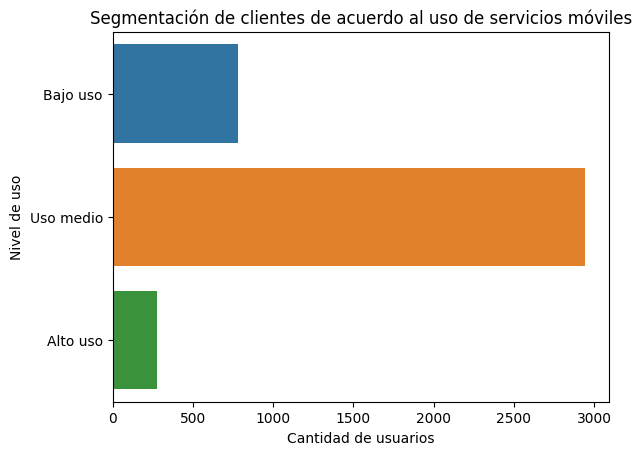

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, y="grupo_uso", order=["Bajo uso", "Uso medio", "Alto uso"])
plt.xlabel("Cantidad de usuarios")
plt.ylabel("Nivel de uso")
plt.title("Segmentación de clientes de acuerdo al uso de servicios móviles")
plt.show()

In [ ]:
print("Características de segmentación por uso:\n", user_profile["grupo_uso"].describe())
print("Conteo de usuarios según su nivel de uso:\n", user_profile["grupo_uso"].value_counts())

Características de segmentación por uso:
 count          4000
unique            3
top       Uso medio
freq           2943
Name: grupo_uso, dtype: object
Conteo de usuarios según su nivel de uso:
 Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


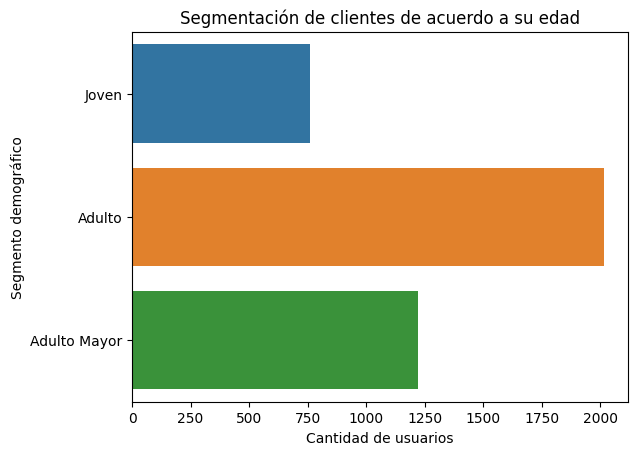

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, y="grupo_edad", order=["Joven", "Adulto", "Adulto Mayor"])
plt.xlabel("Cantidad de usuarios")
plt.ylabel("Segmento demográfico")
plt.title("Segmentación de clientes de acuerdo a su edad")
plt.show()

In [ ]:
print("Características de segmentación por edad:\n", user_profile["grupo_edad"].describe())
print("Conteo de usuarios según su segmento demográfico:\n", user_profile["grupo_edad"].value_counts())

Características de segmentación por edad:
 count       4000
unique         3
top       Adulto
freq        2018
Name: grupo_edad, dtype: object
Conteo de usuarios según su segmento demográfico:
 Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [ ]:
# EXTRA - Análisis cruzado entre grupo_edad y grupo_uso

tabla_segmentos = (
    pd.crosstab(
        user_profile["grupo_edad"],
        user_profile["grupo_uso"],
        normalize="index"
    )
    .mul(100)
    .reindex(index=["Joven", "Adulto", "Adulto Mayor"])
    .reindex(columns=["Bajo uso", "Uso medio", "Alto uso"])
    .round(2)
)

tabla_segmentos

grupo_uso,Bajo uso,Uso medio,Alto uso
grupo_edad,,,
Joven,20.66,72.63,6.71
Adulto,18.04,74.33,7.63
Adulto Mayor,21.03,72.91,6.06



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron 55 edades con sentinel -999 (1.38% de la data), fueron reemplazadas e imputadas con la mediana.
- El atributo city presentó 469 nulos y 96 "?" (2.4% de la data), estos últimos se estandarizaron como nulos.
- Se detectaron 40 fechas de registro en 2026 (1% de la data), valores imposibles para el análisis, por lo que fueron estandarizados como nulos.
- Los nulos en los atributos "duration" y "length" corresponden a valores según el tipo de evento realizado en la tabla "usage" (llamadas o mensajes), por lo que se mantuvieron sin eliminar o imputar.

🔍 **Segmentos por Edad**
- El segmento Adulto, de entre 30 y 59 años, es el más numeroso, con 2,018 usuarios, seguido de Adulto Mayor (1,222) y Joven (760).
- EXTRA - El nivel de uso es bastante similar entre grupos de edad: aproximadamente 73–74% de cada segmento presenta uso medio. Por lo mismo, la data parece indicar que la edad, por si sola, no explica diferencias importantes en el nivel de uso.

📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes pertenece al segmento de Uso Medio con 2,943 usuarios, 73.6%. Los usuarios de Bajo Uso representan 778 clientes (19.5%), mientras que solo 279 (7%) presentan Alto Uso.
- La data sugiere que el comportamiento predominante es un consumo moderado, con un grupo reducido de usuarios intensivos.
- Se valores atípicos mediante el método IQR en cantidad de llamadas, cantidad de mensajes y especialmente en minutos totales de llamadas. Estos casos representan usuarios con niveles de consumo significativamente superiores al resto (outliers) y podrían corresponder tanto a clientes intensivos como a comportamientos inusuales que requieren monitoreo.

➡️ Esto sugiere que ConnectaTel concentra su base de clientes en perfiles de edades variadas (con predominancia en adultos de entre 30 y 59 años) y nivel de uso medio. De igual forma, los usuarios de alto uso parecen representar un segmento con alto potencial comercial, ya que concentran un mayor consumo de llamadas y mensajería, lo que los convierte en candidatos para planes Premium o servicios de mayor valor agregado.

💡 **Recomendaciones**
- Se recomienda diseñar una oferta específica para usuarios de Alto uso, con mayores beneficios en llamadas y mensajería.
- Se insta a evaluar el lanzamiento de oportunidades de upselling en usuarios de Uso medio, debido a que representan más del 70% de la base de clientes.
- Se propone implementar monitoreo sobre los usuarios con consumo extremo, diferenciando clientes intensivos legítimos de posibles anomalías, mejorando la comprensión de este grupo reducido pero significativo para el negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`